### **4.4 Seasonality and Time Series Forecasting with SARIMA**

In this activity, we will forecast time series data while accounting for **seasonality** - the repeating patterns that occur at regular intervals (such as monthly or yearly cycles). We will work with a revised dataset based on the Johnson & Johnson earnings per share example" `JohnsonAndJohnson2.csv`. This dataset records **monthly earnings per share (EPS)** from **January 1949 to December 1955**.

**Data Description**

- `time`: date in `yyyy-mm` format (e.g. `1949-01` for January 1949)

- `JohnsonJohnson`: Monthly earnings per share (EPS)

---

**Responsible AI Considerations**

Before writing any code, take a moment to think critically about the data you are working with.

- **Are there any protected attributes** (e.g. gender, race, age)?

- **Are there observed or unobserved attributes** that might influence the results but are not explicity included in the dataset?

- **Could this dataset introduce bias** - for example, by reflecting only corporate earnings without context, or by excluding economic or policy factors?

While this dataset is financial and appears neutral, **real-world applications** often involve **ethical decisions** - so developing a habit of questioning the data is key. This is something AI agents typically overlook unless explicity trained for it. **Your edge is your ability to interpret, question, and act ethically** - not just compute.

<span style="color:orange;font-weight:bold">Heads up!</span>:

In earlier practicals, you learned to check if a time series is a **random walk**, or if it has **AR/MA components**. We are skipping that here to focus on **seasonality**, but in real projects, **always identify the structure before modelling**.

**Part 1: Setup and Seasonality Analysis**

Import all necessary libraries for time series analysis, modelling, evaluation, and visualisation. These tools will support everything from decomposition and diagnostics to SARIMA modelling and forecasting.

In [1]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller          # for stationarity testing
from statsmodels.tsa.statespace.sarimax import SARIMAX  # for advanced modelling
from statsmodels.graphics.tsaplots import plot_acf      # for autocorrelation plots
from statsmodels.graphics.tsaplots import plot_pacf     # for partial autocorrelation plots
from statsmodels.graphics.gofplots import qqplot        # for Q-Q plots
from statsmodels.stats.diagnostic import acorr_ljungbox # for the Ljung-Box test
from statsmodels.tsa.seasonal import seasonal_decompose # for seasonal decomposition
from statsmodels.tsa.seasonal import STL                # for seasonal decomposition using STL

# Data manipulation
import pandas as pd
import numpy as np

# Utilities
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Model tuning and visual feedback
from tqdm.notebook import tqdm
from itertools import product

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Remember to run this in the terminal to save the current environment's packages to a requirements file:
# python -m pip freeze > requirements.txt

In [2]:
# Read the data
df = pd.read_csv('./data/JohnsonAndJohnson2.csv', index_col='time', parse_dates=True)

# Display the first few rows of the dataset
df.head()

,JohnsonJohnson
time,
1960-01-01,112
1960-02-01,118
1960-03-01,132
1960-04-01,129
1960-05-01,121


Check the structure of the dataset to understand data types and confirm that the `time` column is suitable for time series analysis. If required, convert `time` column into a proper datetime format and set it as the index. This allows us to use pandas' time series tools effectively.

In [3]:
# Check the structure and data types of the dataset
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1960-01-01 to 1971-12-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   JohnsonJohnson  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


Plot the earnings per share over time using the datetime index. This gives a clear visual of trends and seasonality in the data, helping us identify patterns before modelling.

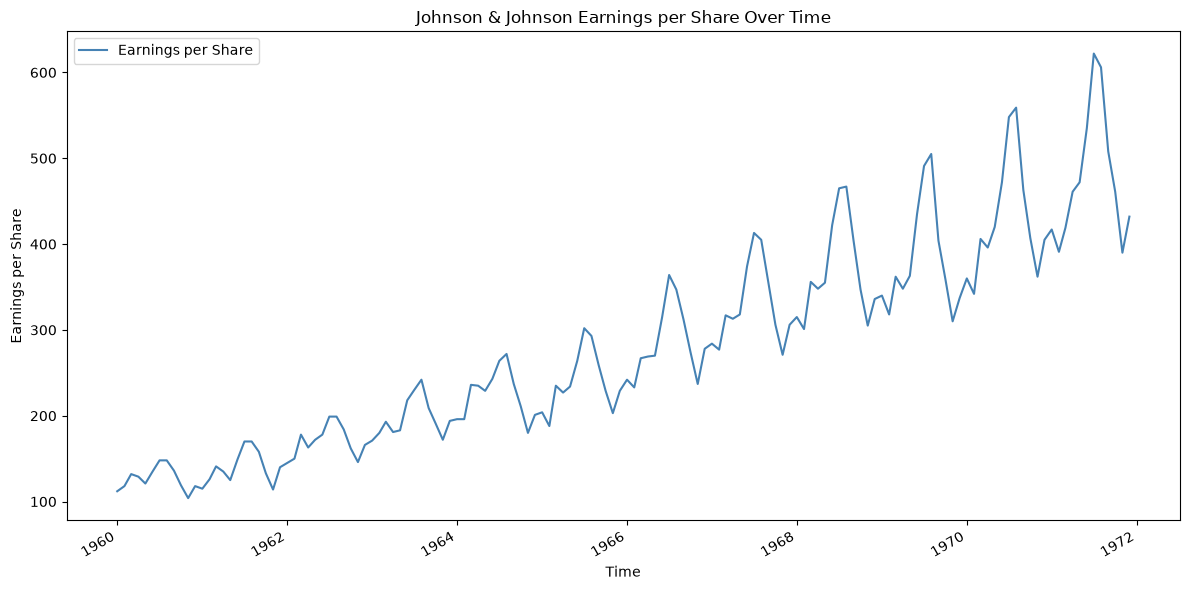

In [4]:
# Create a time series plot of the data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot earnings per share over time
ax.plot(df.index, df['JohnsonJohnson'], linestyle='-', color='steelblue', label='Earnings per Share')
ax.set_title('Johnson & Johnson Earnings per Share Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Earnings per Share')
ax.legend()
fig.autofmt_xdate()  # Auto-format the x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

Let's add vertical lines to highlight the start of each year. This makes the seasonal cycles visually clearer and helps to detect consistent annual patterns in the earnings data.

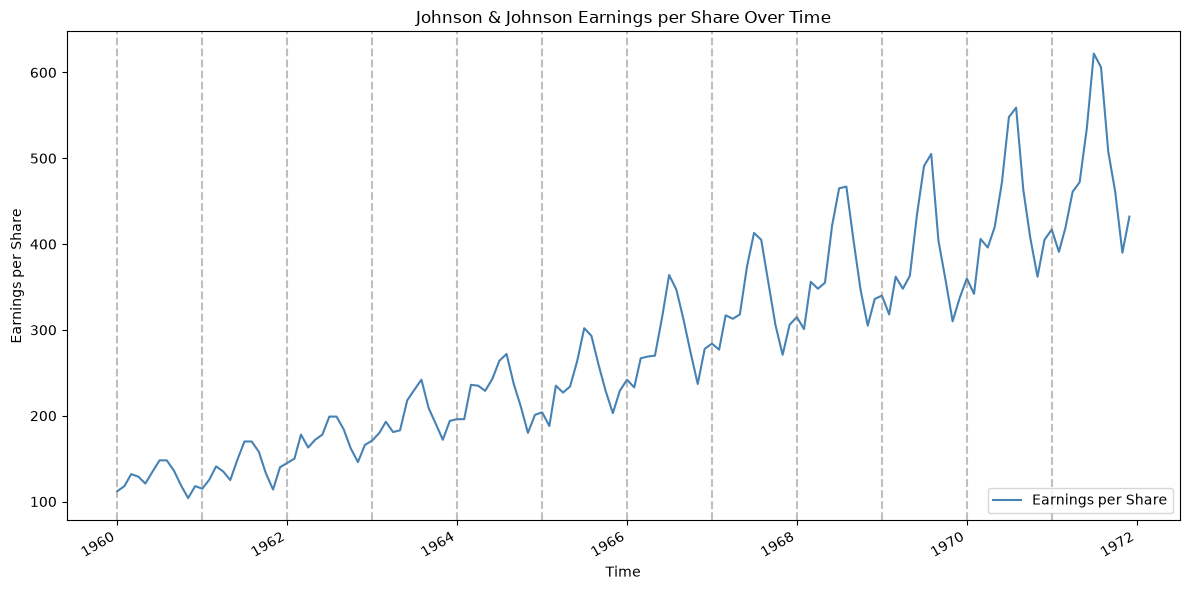

In [5]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['JohnsonJohnson'], linestyle='-', color='steelblue', label='Earnings per Share')

# Add vertical lines at the start of each year to show seasonal cycles
for year in range(df.index.year.min(), df.index.year.max() + 1):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5)
ax.set_title('Johnson & Johnson Earnings per Share Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Earnings per Share')
ax.legend()
fig.autofmt_xdate()  # Auto-format the x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

Another way to clearly see the seasonality is to divide by the components.

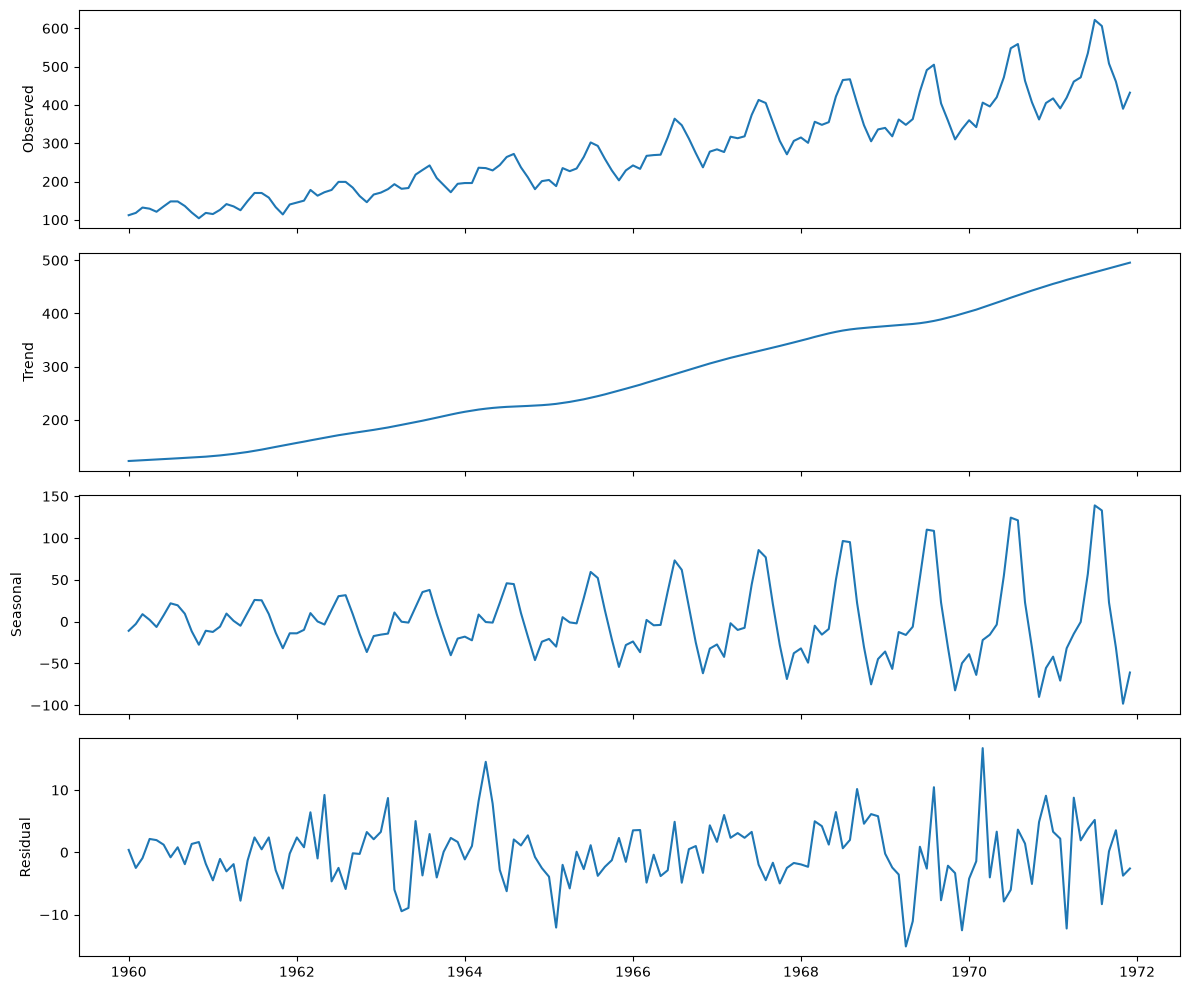

In [6]:
# Decompose the series to observe trend, seasonality, and residuals
decomposition = STL(df['JohnsonJohnson'], period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(12, 10))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residual')

plt.tight_layout()
plt.show()

**Let's forecast with SARIMA model**

Now that we have explored the data and confirmed the presence of seasonality, we will use the **SARIMA (Seasonal ARIMA)** model to forecast easrnings per share. SARIMA extends ARIMA by adding seasonal components, making it a strong choice for data with regular cycles - like our monthly EPS data. The figure below outlines the general procedure for SARIMA modelling. Keep it in mind as we step through model setup, fitting, and evaluation.

In [7]:
# Check for stationarity using the Augmented Dickey-Fuller test
ad_fuller_result = adfuller(df['JohnsonJohnson'])

# Print the results of the ADF test
print('ADF Statistic:', ad_fuller_result[0])
print('p-value:', ad_fuller_result[1])
print('Critical Values:', ad_fuller_result[4])

ADF Statistic: 0.815368879206063
p-value: 0.9918802434376413
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


Since the p-value was high, we cannot reject the null hypothesis - the series is **not stationary**. To address this, we apply **first-order differencing**, which removes trends and helps stabilise the mean. We then rerun the ADF test on the differenced series to check if it is now stationary.

In [8]:
# As p-value is large, we cannot reject the null hypothesis
# the series is not stationary
# Apply first-order differencing
df_diff = np.diff(df['JohnsonJohnson'], n=1)

# Run ADF test on the differenced series
ad_fuller_result_diff = adfuller(df_diff)

# Print the results of the ADF test on the differenced series
print('ADF Statistic (differenced):', ad_fuller_result_diff[0])
print('p-value (differenced):', ad_fuller_result_diff[1])
print('Critical Values (differenced):', ad_fuller_result_diff[4])

ADF Statistic (differenced): -2.829266824170006
p-value (differenced): 0.05421329028382468
Critical Values (differenced): {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


The series is still not stationary after first-order differencing, so before moving on, we **visualise the differenced series** to better understand what might be causing this. This helps us check if a **seasonal pattern** or other structure remains. If seasonality is still present, we will aplly a **seasonal difference** with `m = 12` (monthly data with yearly cycle).

Understanding *why* a series isn't stationary helps us choose the right transformation - not just apply one blindly.

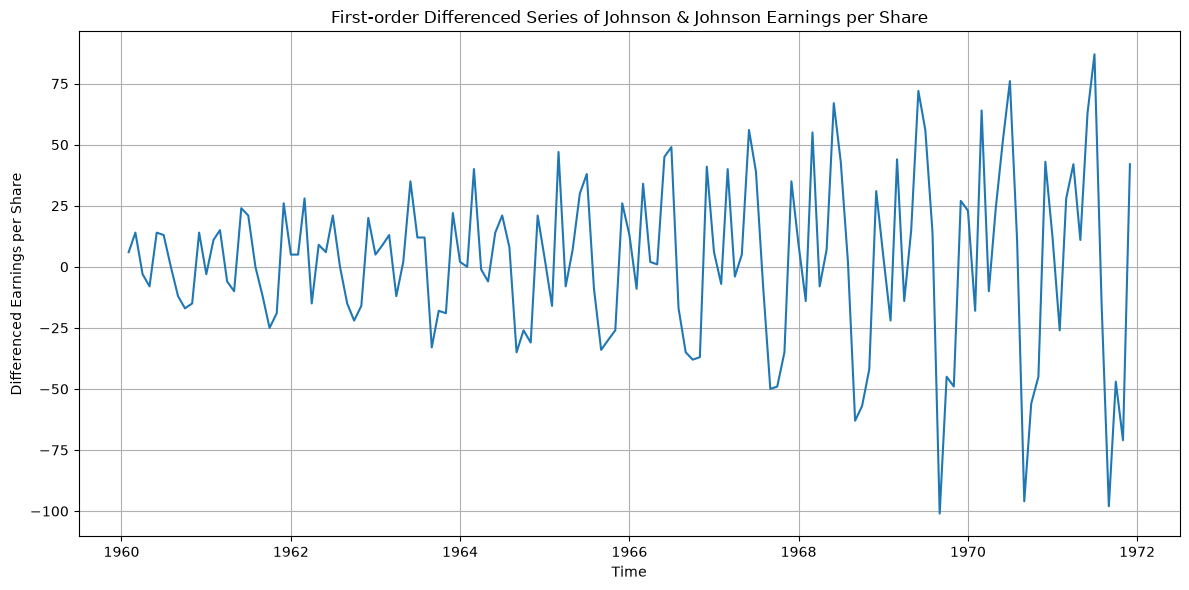

In [9]:
# Plot the first-order differenced series
plt.figure(figsize=(12, 6))
plt.plot(df.index[1:], df_diff)
plt.title('First-order Differenced Series of Johnson & Johnson Earnings per Share')
plt.xlabel('Time')
plt.ylabel('Differenced Earnings per Share')
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

While the long-term trend appears to have been removed, we can still observe:

- **Non-constant variance**: Fluctuations increase toward the end of the series. This suggests potential heteroskedasticity - we won't address it here, but you are encouraged to explore solutions as in previous practicals (e.g., data transformations).

- **Seasonal pattern**: Regular up-down cycles remain visible, indicating that seasonality is not yet removed.

Based on this, we apply a **seasonal difference** with `m = 12` to target the yearly cycle.

In [10]:
# Still not stationary, apply seasonal differencing
# m = 12 for monthly data with annual seasonality
df_diff_seasonal_diff = np.diff(df_diff, n=12)

# ADF test after both first-order and seasonal differencing
ad_fuller_result = adfuller(df_diff_seasonal_diff)

# Print the results of the ADF test after seasonal differencing
print('ADF Statistic (seasonal differenced):', ad_fuller_result[0])
print('p-value (seasonal differenced):', ad_fuller_result[1])
print('Critical Values (seasonal differenced):', ad_fuller_result[4])

ADF Statistic (seasonal differenced): -17.624862360137815
p-value (seasonal differenced): 3.8230468561004324e-30
Critical Values (seasonal differenced): {'1%': np.float64(-3.487517288664615), '5%': np.float64(-2.8865777180380032), '10%': np.float64(-2.5801239192052012)}


After applying seasonal differencing, the ADF test shows:

- **ADF Statistic**: -17.62

- **p-value**: ~0.0

This is clear evidence that the series is now **stationary** - we can confidently proceed with fitting the SARIMA model.

<span style="color:orange;font-weight:bold">Conclusion:</span>: Both trend and seasonal components have been successfully removed.

This is now stationary. So we performed:

- one order of differencing: **d = 1**

- one order of seasonal differencing: **D = 1**

<span style="color:orange;font-weight:bold">Quick Reminder: SARIMA Parameters</span>

**Non-seasonal**:

- `p`: AR (autocorrelation with recent values)
- `d`: Differencing to remove trend
- `q`: MA (smoothing past error terms)

**Seasonal**:

- `P`: Seasonal AR (e.g. January this year vs. January last year)
- `D`: Seasonal differencing (removes repeating yearly trend)
- `Q`: Seasonal MA (seasonal noise patterns)
- `m`: Number of periods person (e.g. 12 for monthly data)

**SARIMA = ARIMA + repeating seasonal behaviour**

In [15]:
def optimise_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:

    results = []

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order=(order[0], d, order[1]), seasonal_order=(order[2], D, order[3], s), simple_differencing=False).fit(disp=False)
        except:
            continue

        aic = model.aic
        results.append([order, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    # Sort the results by AIC in ascending order
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

In [20]:
# We can now define the range of possible values for p,q and P,Q
# Try values 0,1,2,3 for each of p,q,P,Q
ps = range(0, 4, 1)
qs = range(0, 4, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)

# Generate the unique combinations of p,q,P,Q
SARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df['JohnsonJohnson'][:-12]

# Set values of d, D and frequency m
d = 1  # first-order differencing
D = 1  # seasonal differencing
m = 12  # frequency of the seasonal component

SARIMA_result_df = optimise_SARIMA(train, SARIMA_order_list, d, D, m)
SARIMA_result_df

  0%|          | 0/256 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 1, 1, 2)",892.230980
1,"(2, 1, 2, 1)",893.774077
2,"(2, 1, 1, 3)",894.096308
3,"(1, 0, 1, 2)",894.282638
4,"(2, 1, 3, 1)",894.802195
...,...,...
251,"(0, 0, 2, 0)",906.940147
252,"(3, 2, 0, 3)",907.181875
253,"(0, 0, 3, 2)",907.470253
254,"(0, 0, 3, 0)",908.742583


We define the **test set** as the last 12 months of the original time series. As a baseline, we implement a **seasonal naive forecast** - It simply repeats the value from the same month one year earlier. This sets a basic benchmark that our SARIMA model should outperform.

In [21]:
# Define the test set as the last 12 months
test = df.iloc[-12:].copy()

# Create a seasonal naive baseline: use same months from the previous year as predictions
test['seasonal_naive'] = df['JohnsonJohnson'].shift(12).iloc[-12:].values

test

,JohnsonJohnson,seasonal_naive
time,,
1971-01-01,417,360.0
1971-02-01,391,342.0
1971-03-01,419,406.0
1971-04-01,461,396.0
1971-05-01,472,420.0
1971-06-01,535,472.0
1971-07-01,622,548.0
1971-08-01,606,559.0
1971-09-01,508,463.0


We now fit the SARIMA model with the configuration: